## Dune: Imperium — Find undervalued cards (cost vs. properties)

This notebook trains models to predict a card's **Cost** from its **properties**, then ranks cards by **undervaluation**:

- `undervaluation = pred_oof_cost - actual_cost`
- Positive values indicate cards that look **underpriced** relative to similar cards.

Key points:
- Uses **out-of-fold** predictions via Leave-One-Out CV to avoid in-sample leakage.
- Adds **bootstrap stability** to see whether top picks are robust.


In [1]:
import re
from typing import Callable

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import LeaveOneOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")


## Load cards

We use the pre-exported CSV for reproducibility (it lives in the repo).


In [2]:
DATA_PATH = "data/DI_Card_Inventory_v2.4/Deck-Table 1.csv"

# This CSV is exported with ';' separators and embedded newlines inside quoted fields.
df_raw = pd.read_csv(DATA_PATH, sep=";", engine="python")

df = df_raw.copy()
df.columns = df.columns.str.replace("\n", " ", regex=False).str.strip()

# Drop export artifact unnamed first/last columns when present
if len(df.columns) and df.columns[0] == "":
    df = df.drop(columns=[df.columns[0]])
if len(df.columns) and df.columns[-1] == "":
    df = df.drop(columns=[df.columns[-1]])

# Normalize whitespace/newlines across text columns
for c in ["Card Name", "Various", "Agent Ability", "Reveal Ability", "Faction"]:
    if c in df.columns:
        df[c] = (
            df[c]
            .astype(str)
            .str.replace("\r\n|\r|\n", " ", regex=True)
            .str.replace(r"\s+", " ", regex=True)
            .str.strip()
        )

# Coerce cost; '-' becomes NaN (e.g. Foldspace). We'll drop those for cost-based valuation.
df["Cost"] = pd.to_numeric(df["Cost"].replace({"-": np.nan, "": np.nan}), errors="coerce")

df = df.dropna(subset=["Card Name"]).copy()
df = df.drop_duplicates(subset=["Card Name"], keep="first")

df_cost = df.dropna(subset=["Cost"]).copy()
df_cost["Cost"] = df_cost["Cost"].astype(int)

df_cost[["Card Name", "Cost", "Count"]].head(10)


,Card Name,Cost,Count
0,Arrakis Recruiter,2,2
1,Assassination Mission,1,2
2,Bene Gesserit Initiate,3,2
3,Bene Gesserit Sister,3,3
4,Carryall,5,1
5,Chani,5,1
6,Choam Directorship,8,1
7,Crysknife,3,1
8,Dr. Yueh,1,1
9,Duncan Idaho,4,1


## Feature engineering

We build mostly-structured features (spaces, reveals, factions) plus a few robust text-derived signals.


In [3]:
SPACE_COLS = [
    "Green Space",
    "Blue Space",
    "Yellow Space",
    "Emperor Space",
    "Guild Space",
    "Bene Space",
    "Fremen Space",
]


def build_features(df_in: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, list[str]]:
    df = df_in.copy()

    # Normalize spaces (X/x) to boolean
    for c in SPACE_COLS:
        if c in df.columns:
            df[c] = df[c].astype(str).str.strip().str.lower().isin(["x", "true", "1"])
        else:
            df[c] = False

    # Reveal numbers
    for c in ["Reveal persuasion", "Reveal Swords"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c].replace({"-": 0, "": 0}), errors="coerce").fillna(0).astype(int)
        else:
            df[c] = 0

    if "Count" in df.columns:
        df["Count"] = pd.to_numeric(df["Count"], errors="coerce").fillna(0).astype(int)
    else:
        df["Count"] = 1

    df["n_spaces"] = df[SPACE_COLS].sum(axis=1).astype(int)
    df["reveal_total_combat"] = (df["Reveal persuasion"] + df["Reveal Swords"]).astype(int)

    various = df.get("Various", "").astype(str).str.strip()
    df["has_with_buy"] = various.str.lower().str.startswith("with buy:").astype(int)

    def ability_blob(row: pd.Series) -> str:
        parts = [
            str(row.get("Agent Ability", "")),
            str(row.get("Reveal Ability", "")),
            str(row.get("Various", "")),
        ]
        return "\n".join(p for p in parts if p and p != "nan")

    blob = df.apply(ability_blob, axis=1)
    blob_lower = blob.str.lower()

    signed = re.compile(r"([+-])\s*(\d+)")
    df["text_signed_bonus_sum"] = blob.apply(
        lambda s: sum((1 if m.group(1) == "+" else -1) * int(m.group(2)) for m in signed.finditer(s))
    ).astype(int)

    pay = re.compile(r"(?i)pay\s+(\d+)")
    df["text_n_pay"] = blob.apply(lambda s: len(pay.findall(s))).astype(int)
    df["text_or_count"] = blob_lower.str.count(r"\s or \s")

    scale = re.compile(
        r"(?i)(for each|when trashed|when .{0,40}:|if you have|alliance|\bbond\b"
        r"|with another|with \d+ \w+ |each opponent|costs\s+\d+\s+less|including this one)"
    )
    df["text_scales_or_conditional"] = blob.apply(lambda s: int(bool(scale.search(s))))

    fac = df.get("Faction", "-").astype(str).fillna("-")
    df["is_neutral_faction"] = (fac == "-").astype(int)
    df["faction_emperor"] = fac.str.contains("Emperor", regex=False).astype(int)
    df["faction_bene_gesserit"] = fac.str.contains("Bene Gesserit", regex=False).astype(int)
    df["faction_fremen"] = fac.str.contains("Fremen", regex=False).astype(int)
    df["faction_spacing_guild"] = fac.str.contains("Spacing Guild", regex=False).astype(int)

    feature_cols = [
        "Count",
        "Reveal persuasion",
        "Reveal Swords",
        "n_spaces",
        "reveal_total_combat",
        "has_with_buy",
        "text_signed_bonus_sum",
        "text_n_pay",
        "text_or_count",
        "text_scales_or_conditional",
        "is_neutral_faction",
        "faction_emperor",
        "faction_bene_gesserit",
        "faction_fremen",
        "faction_spacing_guild",
        *SPACE_COLS,
    ]

    X = df[feature_cols].copy()
    y = df["Cost"].astype(int)
    return X, y, df, feature_cols


X, y, df_feat, FEATURE_COLS = build_features(df_cost)
X.head(3)


,Count,Reveal persuasion,Reveal Swords,n_spaces,reveal_total_combat,has_with_buy,text_signed_bonus_sum,text_n_pay,text_or_count,text_scales_or_conditional,...,faction_bene_gesserit,faction_fremen,faction_spacing_guild,Green Space,Blue Space,Yellow Space,Emperor Space,Guild Space,Bene Space,Fremen Space
0,2,1,1,1,2,0,1,0,0,0,...,0,0,0,False,True,False,False,False,False,False
1,2,0,1,0,1,0,5,0,0,1,...,0,0,0,False,False,False,False,False,False,False
2,2,1,0,3,1,0,0,0,0,0,...,1,0,0,True,True,True,False,False,False,False


## Models: out-of-fold predictions (LOO)

We compute an out-of-fold prediction for every card using Leave-One-Out CV.


In [4]:
def oof_predictions(model_factory: Callable[[], object], X: pd.DataFrame, y: pd.Series) -> np.ndarray:
    loo = LeaveOneOut()
    preds = np.empty(len(y), dtype=float)
    for tr, te in loo.split(X):
        m = model_factory()
        m.fit(X.iloc[tr], y.iloc[tr])
        preds[te] = m.predict(X.iloc[te])
    return preds


rf_params = {
    "n_estimators": 512,
    "random_state": 42,
    "ccp_alpha": 0.06,
    "n_jobs": -1,
}
pred_rf_oof = oof_predictions(lambda: RandomForestRegressor(**rf_params), X, y)

enet_factory = lambda: Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "enet",
            ElasticNetCV(
                l1_ratio=[0.25, 0.5, 0.75, 0.9, 0.99],
                cv=5,
                random_state=42,
                max_iter=25_000,
            ),
        ),
    ]
)
pred_enet_oof = oof_predictions(enet_factory, X, y)

print("Baseline MAE (predict mean):", round(mean_absolute_error(y, np.full(len(y), y.mean())), 3))
print(
    "RF LOO MAE:",
    round(mean_absolute_error(y, pred_rf_oof), 3),
    "RMSE:",
    round(root_mean_squared_error(y, pred_rf_oof), 3),
)
print(
    "ENet LOO MAE:",
    round(mean_absolute_error(y, pred_enet_oof), 3),
    "RMSE:",
    round(root_mean_squared_error(y, pred_enet_oof), 3),
)


Baseline MAE (predict mean): 1.489
RF LOO MAE: 1.344 RMSE: 1.682
ENet LOO MAE: 1.449 RMSE: 1.734


## Undervaluation table

Positive residuals mean the model thinks the card should cost more than it does.


In [5]:
results = (
    df_feat.assign(
        pred_rf_oof=pred_rf_oof,
        pred_enet_oof=pred_enet_oof,
    )
    .assign(
        undervalue_rf=lambda d: d["pred_rf_oof"] - d["Cost"],
        undervalue_enet=lambda d: d["pred_enet_oof"] - d["Cost"],
        undervalue_avg=lambda d: 0.5 * (d["undervalue_rf"] + d["undervalue_enet"]),
    )
    .sort_values("undervalue_avg", ascending=False)
)

results[["Card Name", "Cost", "pred_rf_oof", "pred_enet_oof", "undervalue_avg"]].head(15)


,Card Name,Cost,pred_rf_oof,pred_enet_oof,undervalue_avg
8,Dr. Yueh,1,4.680386,3.335210,3.007798
1,Assassination Mission,1,3.668045,3.765443,2.716744
23,Missionaria Protectiva,1,2.986287,3.013195,1.999741
29,Sardaukar Infantry,1,2.992687,2.933692,1.963189
31,Scout,1,2.482778,3.370222,1.926500
19,Imperial Spy,2,3.324300,3.690509,1.507404
37,Spice Smugglers,2,3.132641,3.848961,1.490801
39,Test of Humanity,3,4.563130,4.186096,1.374613
3,Bene Gesserit Sister,3,4.268423,4.241807,1.255115
16,Guild Bankers,3,4.063836,4.216294,1.140065


## Quick visualization

This scatter is a sanity check: predicted costs should broadly track actual costs.


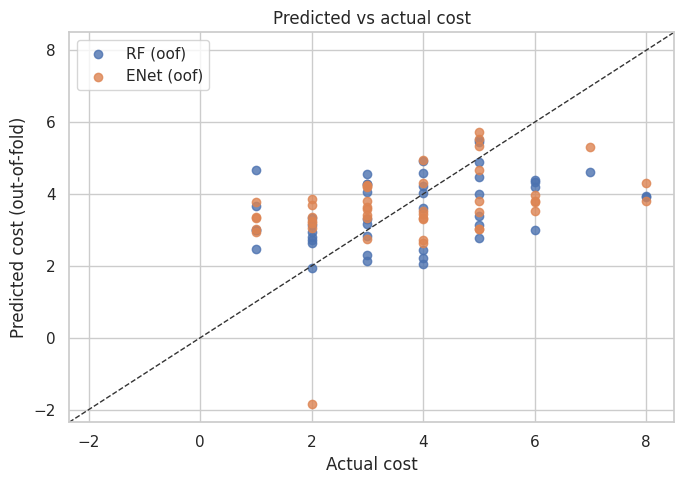

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(results["Cost"], results["pred_rf_oof"], alpha=0.8, label="RF (oof)")
ax.scatter(results["Cost"], results["pred_enet_oof"], alpha=0.8, label="ENet (oof)")
lim = [min(results["Cost"].min(), results["pred_rf_oof"].min(), results["pred_enet_oof"].min()) - 0.5,
       max(results["Cost"].max(), results["pred_rf_oof"].max(), results["pred_enet_oof"].max()) + 0.5]
ax.plot(lim, lim, color="#333", linewidth=1, linestyle="--")
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel("Actual cost")
ax.set_ylabel("Predicted cost (out-of-fold)")
ax.set_title("Predicted vs actual cost")
ax.legend()
plt.tight_layout()
plt.show()


## Bootstrap stability (top-k frequency)

This helps distinguish genuinely underpriced candidates from small-sample noise.


In [7]:
def bootstrap_topk_stability(
    model_factory: Callable[[], object],
    X: pd.DataFrame,
    y: pd.Series,
    names: pd.Series,
    *,
    n_boot: int = 300,
    topk: int = 10,
    random_state: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    counts = {n: 0 for n in names.tolist()}

    y_np = y.to_numpy()
    for _ in range(n_boot):
        idx = rng.integers(0, len(y_np), size=len(y_np))
        m = model_factory()
        m.fit(X.iloc[idx], y.iloc[idx])
        pred = m.predict(X)
        underv = pred - y_np
        top_idx = np.argsort(-underv)[:topk]
        for i in top_idx:
            counts[names.iloc[i]] += 1

    out = (
        pd.DataFrame({"Card Name": list(counts.keys()), "topk_hits": list(counts.values())})
        .assign(topk_rate=lambda d: d["topk_hits"] / n_boot)
        .sort_values(["topk_hits", "Card Name"], ascending=[False, True])
    )
    return out


st_rf = bootstrap_topk_stability(
    lambda: RandomForestRegressor(**rf_params),
    X,
    y,
    df_feat["Card Name"],
    n_boot=300,
    topk=10,
)
st_en = bootstrap_topk_stability(
    enet_factory,
    X,
    y,
    df_feat["Card Name"],
    n_boot=300,
    topk=10,
)

stability = (
    st_rf.rename(columns={"topk_hits": "topk_hits_rf", "topk_rate": "topk_rate_rf"})
    .merge(
        st_en.rename(columns={"topk_hits": "topk_hits_enet", "topk_rate": "topk_rate_enet"}),
        on="Card Name",
        how="outer",
    )
    .fillna(0)
    .merge(results[["Card Name", "Cost", "undervalue_avg"]], on="Card Name", how="left")
    .assign(topk_hits_avg=lambda d: 0.5 * (d["topk_hits_rf"] + d["topk_hits_enet"]))
    .sort_values(["topk_hits_avg", "undervalue_avg"], ascending=[False, False])
)

stability.head(20)


,Card Name,topk_hits_rf,topk_rate_rf,topk_hits_enet,topk_rate_enet,Cost,undervalue_avg,topk_hits_avg
32,Scout,244,0.813333,287,0.956667,1,1.926500,265.5
9,Dr. Yueh,255,0.850000,272,0.906667,1,3.007798,263.5
2,Assassination Mission,244,0.813333,277,0.923333,1,2.716744,260.5
24,Missionaria Protectiva,250,0.833333,205,0.683333,1,1.999741,227.5
30,Sardaukar Infantry,215,0.716667,158,0.526667,1,1.963189,186.5
40,Test of Humanity,189,0.630000,141,0.470000,3,1.374613,165.0
38,Spice Smugglers,115,0.383333,186,0.620000,2,1.490801,150.5
17,Guild Bankers,172,0.573333,94,0.313333,3,1.140065,133.0
37,Spice Hunter,116,0.386667,129,0.430000,2,1.080036,122.5
8,Crysknife,198,0.660000,46,0.153333,3,0.958931,122.0


## Final: recommended undervalued candidates

A practical filter is: high `undervalue_avg` and high bootstrap `topk_hits_avg`.


In [8]:
final = (
    results.merge(
        stability[
            [
                "Card Name",
                "topk_hits_rf",
                "topk_hits_enet",
                "topk_hits_avg",
                "topk_rate_rf",
                "topk_rate_enet",
            ]
        ],
        on="Card Name",
        how="left",
    )
    .sort_values(["topk_hits_avg", "undervalue_avg"], ascending=[False, False])
)

final[["Card Name", "Cost", "undervalue_avg", "topk_rate_rf", "topk_rate_enet"]].head(15)


,Card Name,Cost,undervalue_avg,topk_rate_rf,topk_rate_enet
4,Scout,1,1.926500,0.813333,0.956667
0,Dr. Yueh,1,3.007798,0.850000,0.906667
1,Assassination Mission,1,2.716744,0.813333,0.923333
2,Missionaria Protectiva,1,1.999741,0.833333,0.683333
3,Sardaukar Infantry,1,1.963189,0.716667,0.526667
7,Test of Humanity,3,1.374613,0.630000,0.470000
6,Spice Smugglers,2,1.490801,0.383333,0.620000
9,Guild Bankers,3,1.140065,0.573333,0.313333
10,Spice Hunter,2,1.080036,0.386667,0.430000
12,Crysknife,3,0.958931,0.660000,0.153333
